In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

dataset = pd.read_csv("PokemonDatabase.csv")
dataset.head()

,Pokemon Id,Pokedex Number,Pokemon Name,Classification,Alternate Form Name,Original Pokemon ID,Legendary Type,Pokemon Height,Pokemon Weight,Primary Type,...,Base Stat Total,Catch Rate,Experience Growth,Experience Growth Total,Primary Egg Group,Secondary Egg Group,Egg Cycle Count,Pre-Evolution Pokemon Id,Evolution Details,Power Ranking
0,1,1,"""Bulbasaur""","""Seed Pokémon""",NaN,NaN,NaN,0.7,6.9,"""Grass""",...,318,45,"""Medium Slow""",1059860,"""Monster""","""Grass""",20,NaN,NaN,F
1,2,2,"""Ivysaur""","""Seed Pokémon""",NaN,NaN,NaN,1.0,13.0,"""Grass""",...,405,45,"""Medium Slow""",1059860,"""Monster""","""Grass""",20,1.0,"""Level 16""",F
2,3,3,"""Venusaur""","""Seed Pokémon""",NaN,NaN,NaN,2.0,100.0,"""Grass""",...,525,45,"""Medium Slow""",1059860,"""Monster""","""Grass""",20,2.0,"""Level 32""",C
3,4,3,"""Venusaur""","""Seed Pokémon""","""Mega""",3.0,NaN,2.4,155.5,"""Grass""",...,625,45,"""Medium Slow""",1059860,"""Monster""","""Grass""",20,NaN,NaN,B
4,1526,3,"""Venusaur""","""Seed Pokémon""","""Gigantamax""",3.0,NaN,24.0,0.0,"""Grass""",...,525,45,"""Medium Slow""",1059860,"""Monster""","""Grass""",20,NaN,NaN,S


In [14]:
from sklearn.model_selection import train_test_split

features = ["Health Stat", "Attack Stat", "Defense Stat", "Special Attack Stat", "Special Defense Stat", "Speed Stat", "Base Stat Total"]

tier_map = {'G': 0,'F': 1, 'E': 2, 'D': 3, 'C': 4, 'B': 5, 'A': 6, 'S': 7}
dataset['Power Ranking'] = dataset['Power Ranking'].astype(str).str.replace('"', '').str.strip().map(tier_map)

X = dataset[features].values
y = dataset["Power Ranking"].values

X_train, X_test_tmp, y_train, y_test_tmp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_dev, X_test, y_dev, y_test = train_test_split(X_test_tmp, y_test_tmp, test_size=0.50, random_state=42, stratify=y_test_tmp)

## Model using standard dataset

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_dev = scaler.transform(X_dev)
X_test = scaler.transform(X_test)

model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    alpha=0.0001,
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

/home/puchan/Projects/Pokemon-strength-classifier/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


### Accuracy

In [16]:
y_train_pred = model.predict(X_train)
y_dev_pred = model.predict(X_dev)

train_accuracy = accuracy_score(y_train, y_train_pred)
print("Train accuracy:", train_accuracy)
dev_accuracy = accuracy_score(y_dev, y_dev_pred)
print("Dev accuracy:", dev_accuracy)

class_report = classification_report(y_dev, y_dev_pred, target_names=["G", "F", "E", "D", "C", "B", "A", "S"])
print("Classification Report:\n", class_report)

Train accuracy: 0.7341101694915254
Dev accuracy: 0.693069306930693
Classification Report:
               precision    recall  f1-score   support

           G       0.92      0.92      0.92        26
           F       0.95      1.00      0.97        55
           E       0.70      0.90      0.79        41
           D       0.25      0.19      0.21        16
           C       0.29      0.14      0.19        14
           B       0.39      0.55      0.46        20
           A       0.38      0.29      0.33        17
           S       0.60      0.23      0.33        13

    accuracy                           0.69       202
   macro avg       0.56      0.53      0.53       202
weighted avg       0.67      0.69      0.67       202



### Confusion matrix

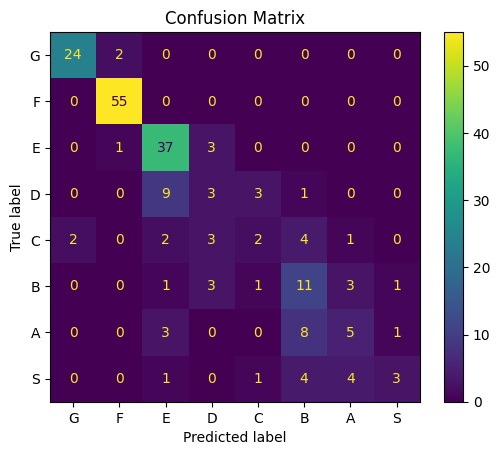

In [17]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_dev, y_dev_pred)

display_labels = ["G","F", "E", "D", "C", "B", "A", "S"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Model using dataset after PCA

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_dev_pca = pca.transform(X_dev)
X_test_pca = pca.transform(X_test)

pca_model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    alpha=0.0001,
    max_iter=1000,
    random_state=42
)

pca_model.fit(X_train_pca, y_train)

/home/puchan/Projects/Pokemon-strength-classifier/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


### Accuracy

In [19]:
y_train_pred = pca_model.predict(X_train_pca)
y_dev_pred = pca_model.predict(X_dev_pca)

train_accuracy = accuracy_score(y_train, y_train_pred)
print("Train accuracy:", train_accuracy)
dev_accuracy = accuracy_score(y_dev, y_dev_pred)
print("Dev accuracy:", dev_accuracy)

class_report = classification_report(y_dev, y_dev_pred, target_names=["G", "F", "E", "D", "C", "B", "A", "S"])
print("Classification Report:\n", class_report)

Train accuracy: 0.7330508474576272
Dev accuracy: 0.698019801980198
Classification Report:
               precision    recall  f1-score   support

           G       0.92      0.92      0.92        26
           F       0.93      1.00      0.96        55
           E       0.70      0.90      0.79        41
           D       0.27      0.19      0.22        16
           C       0.18      0.14      0.16        14
           B       0.47      0.70      0.56        20
           A       0.75      0.18      0.29        17
           S       0.38      0.23      0.29        13

    accuracy                           0.70       202
   macro avg       0.57      0.53      0.52       202
weighted avg       0.68      0.70      0.67       202



### Plot visualization

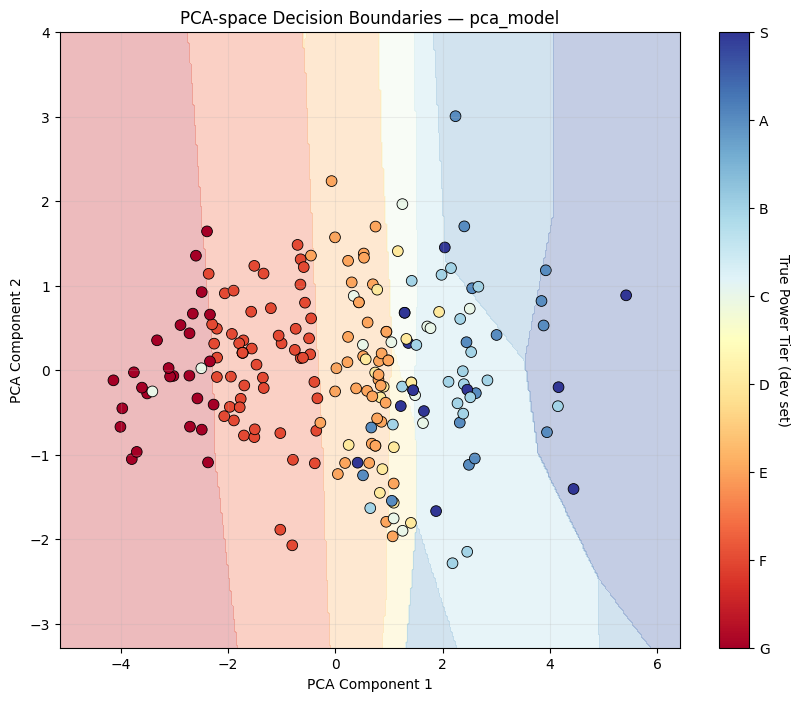

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

label_names = ["G", "F", "E", "D", "C", "B", "A", "S"]

x_min, x_max = X_dev_pca[:, 0].min() - 1.0, X_dev_pca[:, 0].max() + 1.0
y_min, y_max = X_dev_pca[:, 1].min() - 1.0, X_dev_pca[:, 1].max() + 1.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
grid = np.c_[xx.ravel(), yy.ravel()]

Z = pca_model.predict(grid)
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(10, 8))
cmap = plt.cm.RdYlBu
plt.contourf(xx, yy, Z, levels=np.arange(-0.5, len(label_names), 1), cmap=cmap, alpha=0.3)

sc = plt.scatter(X_dev_pca[:, 0], X_dev_pca[:, 1], c=y_dev, cmap=cmap, s=60, edgecolor="k", linewidth=0.6)

cbar = plt.colorbar(sc, ticks=np.arange(len(label_names)))
cbar.ax.set_yticklabels(label_names)
cbar.set_label('True Power Tier (dev set)', rotation=270, labelpad=15)

plt.title("PCA-space Decision Boundaries — pca_model")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True, alpha=0.2)
plt.show()